In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

from flax import nnx

In [3]:
from diffusion_mri_models import Dti, Ball, Stick, add_mri_noise

In [4]:
class BallAndStick(nnx.Module, experimental_pytree=True):
    
    def __init__(self,num_sticks: int, rngs):
        self.num_sticks = num_sticks
        self.num_components = 1 + num_sticks + 1 # Ball + Sticks + Noise
        # Ball parameters
        self.theta_ball = nnx.Param(jax.random.normal(rngs.next(), (1)))
        self.phi_ball = nnx.Param(jax.random.normal(rngs.next(), (1)))

        self.thetas_stick = []
        self.phis_stick = []
    
        for i in range(num_sticks):
            self.thetas_stick.append(nnx.Param(jax.random.normal(rngs.next(), (3))))
            if i < num_sticks-1:
                self.phis_stick.append(nnx.Param(jax.random.normal(rngs.next(), (1))))

        self.theta_sigma = nnx.Param(jax.random.normal(rngs.next(), (1)))

        

    def __call__(self, component_mask, bvals, bvecs, rng):
        ball = Ball.from_theta(self.theta_ball.value)
        sticks = [Stick.from_theta(theta) for theta in self.thetas_stick]

        phi0 = jax.nn.sigmoid(self.phi_ball.value) * component_mask[0]
        S_ball = ball.signal(bvals, bvecs) * phi0

        S_total = S_ball

        for i, stick in enumerate(sticks[:-1]):
            phi_i =  jax.nn.sigmoid(self.phis_stick[i].value) * (1-phi0) * component_mask[i+1]
            phi0 += phi_i # update the total volume fraction
            S_total += stick.signal(bvals, bvecs)*phi_i

        # Last stick
        if len(sticks) > 0:
            S_total += sticks[-1].signal(bvals, bvecs) * (1-phi0) * component_mask[-2]

        std = jax.nn.sigmoid(self.theta_sigma.value)*0.1 * component_mask[-1]
        S_noisy = add_mri_noise(rng,S_total, std)

        return S_noisy


In [5]:
simulator = BallAndStick(2, nnx.Rngs(0))

bvals = jnp.array([0]*10 + [1000]*90)
bvecs = jax.random.normal(jax.random.key(1), (100,3))
component_mask = jnp.array([1]*simulator.num_components)
component_mask

2024-12-04 10:50:34.867680: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.5 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


Array([1, 1, 1, 1], dtype=int32)

In [6]:
component_mask = jnp.array([1,1,1,0])
s = simulator(component_mask, bvals, bvecs, jax.random.key(9))

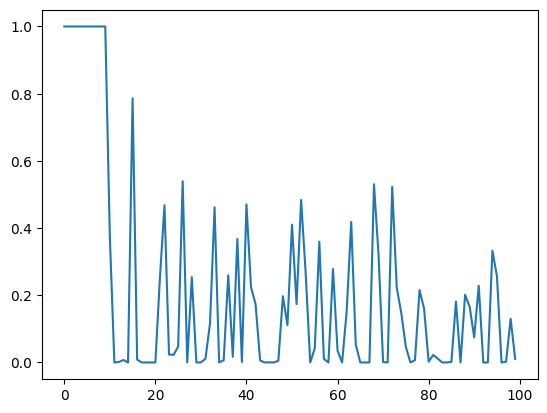

In [7]:
plt.plot(s)

In [8]:
graphdef, thetas = nnx.split(simulator, nnx.Param)
flat_thetas, unflatten = jax.flatten_util.ravel_pytree(thetas)


NUM_AQUISITIONS = 100

def generate_data(key):
    rng_component_mask, rng_params, rng_simulator = jax.random.split(key,3)
    component_mask = jax.random.bernoulli(rng_component_mask, 0.3, (simulator.num_components,))
    params = jax.random.normal(rng_params, flat_thetas.shape)
    params = unflatten(params)
    f = nnx.merge(graphdef, params)
    S = f(component_mask, bvals, bvecs, rng_simulator)
    return component_mask, params, S




In [9]:
from functools import partial


@partial(jax.jit, static_argnums=(1,))  
def batch_sampler(key, batch_size=512):
    keys = jax.random.split(key, batch_size)
    components, thetas, signal= jax.vmap(lambda k:generate_data(k))(keys)
    xs = signal.reshape((batch_size, -1))
    return components, thetas, xs

def train_data_generator(key, batch_size):
    while True:
        key, subkey = jax.random.split(key)
        yield batch_sampler(subkey, batch_size)

train_data = train_data_generator(jax.random.PRNGKey(0), 1024)

In [10]:
from models import ModelIdentificationDecoder, MLP

In [230]:
embedding_net = MLP([NUM_AQUISITIONS, 100,100], rngs=nnx.Rngs(0))
decoder = ModelIdentificationDecoder(100,100, rngs=nnx.Rngs(1), num_heads=4, num_layers=6, widening_factor=4, context_net=embedding_net)


class Model(nnx.Module, experimental_pytree=True):
    def __init__(self, num_components,decoder):
        self.decoder = decoder
        self.num_components = num_components
    def __call__(self, components, thetas, x_o, return_latents=False):
        logits = self.decoder(components, x_o, return_latents=return_latents)
        return logits
    
    def sample_components(self,rng, num_samples,x_o):
        rngs = jax.random.split(rng, num_samples)
        return jax.vmap(self.decoder.sample, in_axes=(0,None,None))(rngs, x_o, self.num_components)

model_selection = Model(4,decoder)
params1 = nnx.state(model_selection, nnx.Param)

In [231]:
from models import ModelIdentificationDecoder, MLP, Simformer, PyTreeTokenizer, EDM

dims_by_component = [1,1,1,1,3,3]
compartments_to_params = {0:[0,2], 1:[1,4], 2:[1,5], 3: [3]}
node_ids = list(range(len(dims_by_component)))
embed_nets = [nnx.Linear(dims_by_component[i], 150, rngs=nnx.Rngs(1),use_bias=False) for i in range(len(dims_by_component))]
decode_nets = [nnx.Linear(200, dims_by_component[i], rngs=nnx.Rngs(2),use_bias=False) for i in range(len(dims_by_component))]

def embedding_net(h):
    return h[:, -1, :]

tokenizer = PyTreeTokenizer(dims_by_component, embed_nets, decode_nets, rngs=nnx.Rngs(3))
simformer = Simformer(tokenizer, nnx.Rngs(4), model_dim=200, context_embed=embedding_net)

params_selection = EDM(simformer)
params2 = nnx.state(params_selection, nnx.Param)

In [232]:
components, thetas, xs = next(train_data)

In [233]:
logits, latents = model_selection(components, thetas, xs, return_latents=True)
flatten_thetas = jax.tree_util.tree_flatten(thetas)[0]
flat_thetas = jnp.concatenate(flatten_thetas, axis=-1)

params_selection(jnp.ones((1024,1)), flat_thetas, node_ids, condition_mask=None, context=latents)

[1 2 3 4 7]
(1024, 6, 200)
(1024, 4, 100)
(1024, 1, 100) (1024, 1, 100)
(1024, 1, 200)


Array([[ 0.98 ,  1.26 ,  0.937, ...,  0.706, -0.612, -1.658],
       [-0.708,  1.047,  0.928, ..., -0.905,  0.014,  2.402],
       [ 1.133, -0.609,  0.963, ..., -1.083,  0.78 ,  0.011],
       ...,
       [-1.117, -0.645,  0.686, ...,  1.624,  0.042, -0.589],
       [ 0.312,  0.018,  1.631, ..., -0.688,  1.171, -0.924],
       [ 0.292,  0.478, -0.312, ..., -0.044, -0.722,  2.197]],      dtype=float32)

In [234]:
#attention_masks = components[:, None, :] + components[:, :, None] + jnp.eye(4, dtype=jnp.bool_)[None, :, :]

In [235]:
#attention_masks[1]

In [243]:
import optax 

scheduler_lr = optax.cosine_onecycle_schedule(20_000, 5e-4)
optimizer = optax.chain(optax.adaptive_grad_clip(10.), optax.ema(0.01), optax.adam(scheduler_lr))
params = params1, params2
@jax.jit
def loss_fn(params, data, rng):
    nnx.update(model_selection, params[0])
    components, thetas, xs = data

    logits, latents = model_selection(components,thetas, xs, return_latents=True)

    loss_model_selection =  optax.sigmoid_binary_cross_entropy(logits, components).sum()

    flatten_thetas = jax.tree_util.tree_flatten(thetas)[0]
    flat_thetas = jnp.concatenate(flatten_thetas, axis=-1)
    loss = params_selection.loss(params[1], rng=rng, data=flat_thetas, node_ids=node_ids, condition_mask=None,context=latents)


    print(loss_model_selection, loss)
    return loss_model_selection + 5*loss

@jax.jit
def update(params, opt_state, data, rng):
    grads = jax.grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state



In [244]:
opt_state = optimizer.init(params)

In [245]:
key = jax.random.PRNGKey(2)
for i in range(20_000):
    key, subkey = jax.random.split(key)
    data = next(train_data)
    params, opt_state = update(params, opt_state, data, subkey)
    if i % 100 == 0:
        print(loss_fn(params, data,key))

[1 2 3 4 7]
(1024, 6, 200)
(1024, 4, 100)
(1024, 1, 100) (1024, 1, 100)
(1024, 1, 200)
Traced<ShapedArray(float32[])>with<DynamicJaxprTrace(level=4/0)> Traced<ShapedArray(float32[])>with<DynamicJaxprTrace(level=4/0)>
2782.5364
2285.3657
2055.3105
1918.7585
1705.3715
1561.8209
1519.2242
1459.5039
1428.4128
1170.5128
1046.2341
948.04315
926.8086
889.9329
928.83453
792.45435
836.87524
773.9916
767.5401
663.3395
736.5881
747.4751
744.64246
702.8739
627.8726
526.9574
826.3141
660.3037
519.16345
547.7854
597.50696
522.02686
494.03857
495.82056
502.30176
587.7894
415.2226
515.5063
472.2517
438.40213
412.33505
393.97003
445.2456
393.3491
472.4301
410.332
446.23062
423.6795
371.74594
352.3178
382.54614
376.627
392.52814
377.47083
343.78674
566.53906
382.8779
325.64172
328.88623
395.76086
341.92426
381.40613
376.19974
317.88205
401.60574
316.5146
330.75592
327.87286
305.66187
337.68103
313.23764
329.47205
319.41962
289.74625
321.26196
352.22592
323.89346
258.10184
342.7238
296.79456
339.5211
313

In [246]:
nnx.update(model_selection, params[0])
nnx.update(params_selection, params[1])

In [247]:
components, thetas, xs = next(train_data)

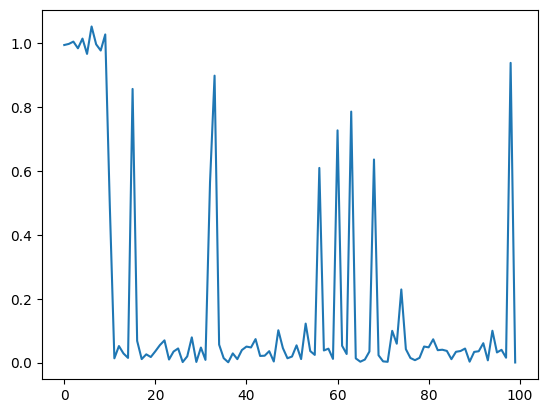

[False False  True  True] [0.02 0.   1.   0.98]


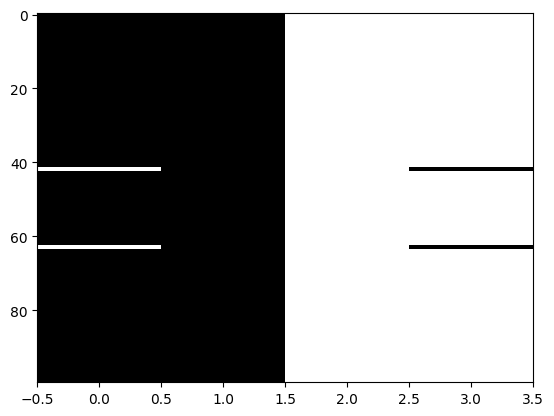

In [308]:
idx = 19

components_pred = model_selection.sample_components(jax.random.PRNGKey(4),100, xs[idx])


plt.plot(xs[idx])
plt.show()
print(components[idx], components_pred.mean(0))
plt.imshow(components_pred, aspect='auto', cmap="Greys_r")


In [309]:
component = components_pred[0]
_, latents = model_selection(component, None, xs[idx][None,:], return_latents=True)

In [310]:
from probjax.utils.odeint import odeint

def sample(rng, context):
    model = params_selection
    eps = jax.random.normal(rng, (10,)) * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(100)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t,x, context=context, node_ids=node_ids, condition_mask=None)
        return (f -0.5*g**2*score).reshape(x.shape)

    return odeint(drift, eps,ts, method="heun")[-1]


from probjax.utils.sdeint import sdeint

def sample(rng, context):
    model = params_selection
    rng_init, rng_sample = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (10,))  * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(200)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t,x)
        score = model.score(t,x[None,...], context=context, node_ids=node_ids, condition_mask=None).squeeze(0)

        drift_backward = f - g**2 * score
        return drift_backward
    
    def diffusion(t, x):
        t = jnp.atleast_1d(t)
        g = model.diffusion(t,x)
        return g
    
    return sdeint(rng_sample,drift, diffusion, eps, ts, method="euler_maruyama")[-1]
    

    
    

In [311]:
thetas_pred = jax.vmap(lambda k: sample(k, latents[None,...]))(jax.random.split(jax.random.PRNGKey(0), 1000))



[1 2 3 4 7]
(1, 6, 200)
(1, 4, 100)
(1, 1, 100) (1, 1, 100)
(1, 1, 200)


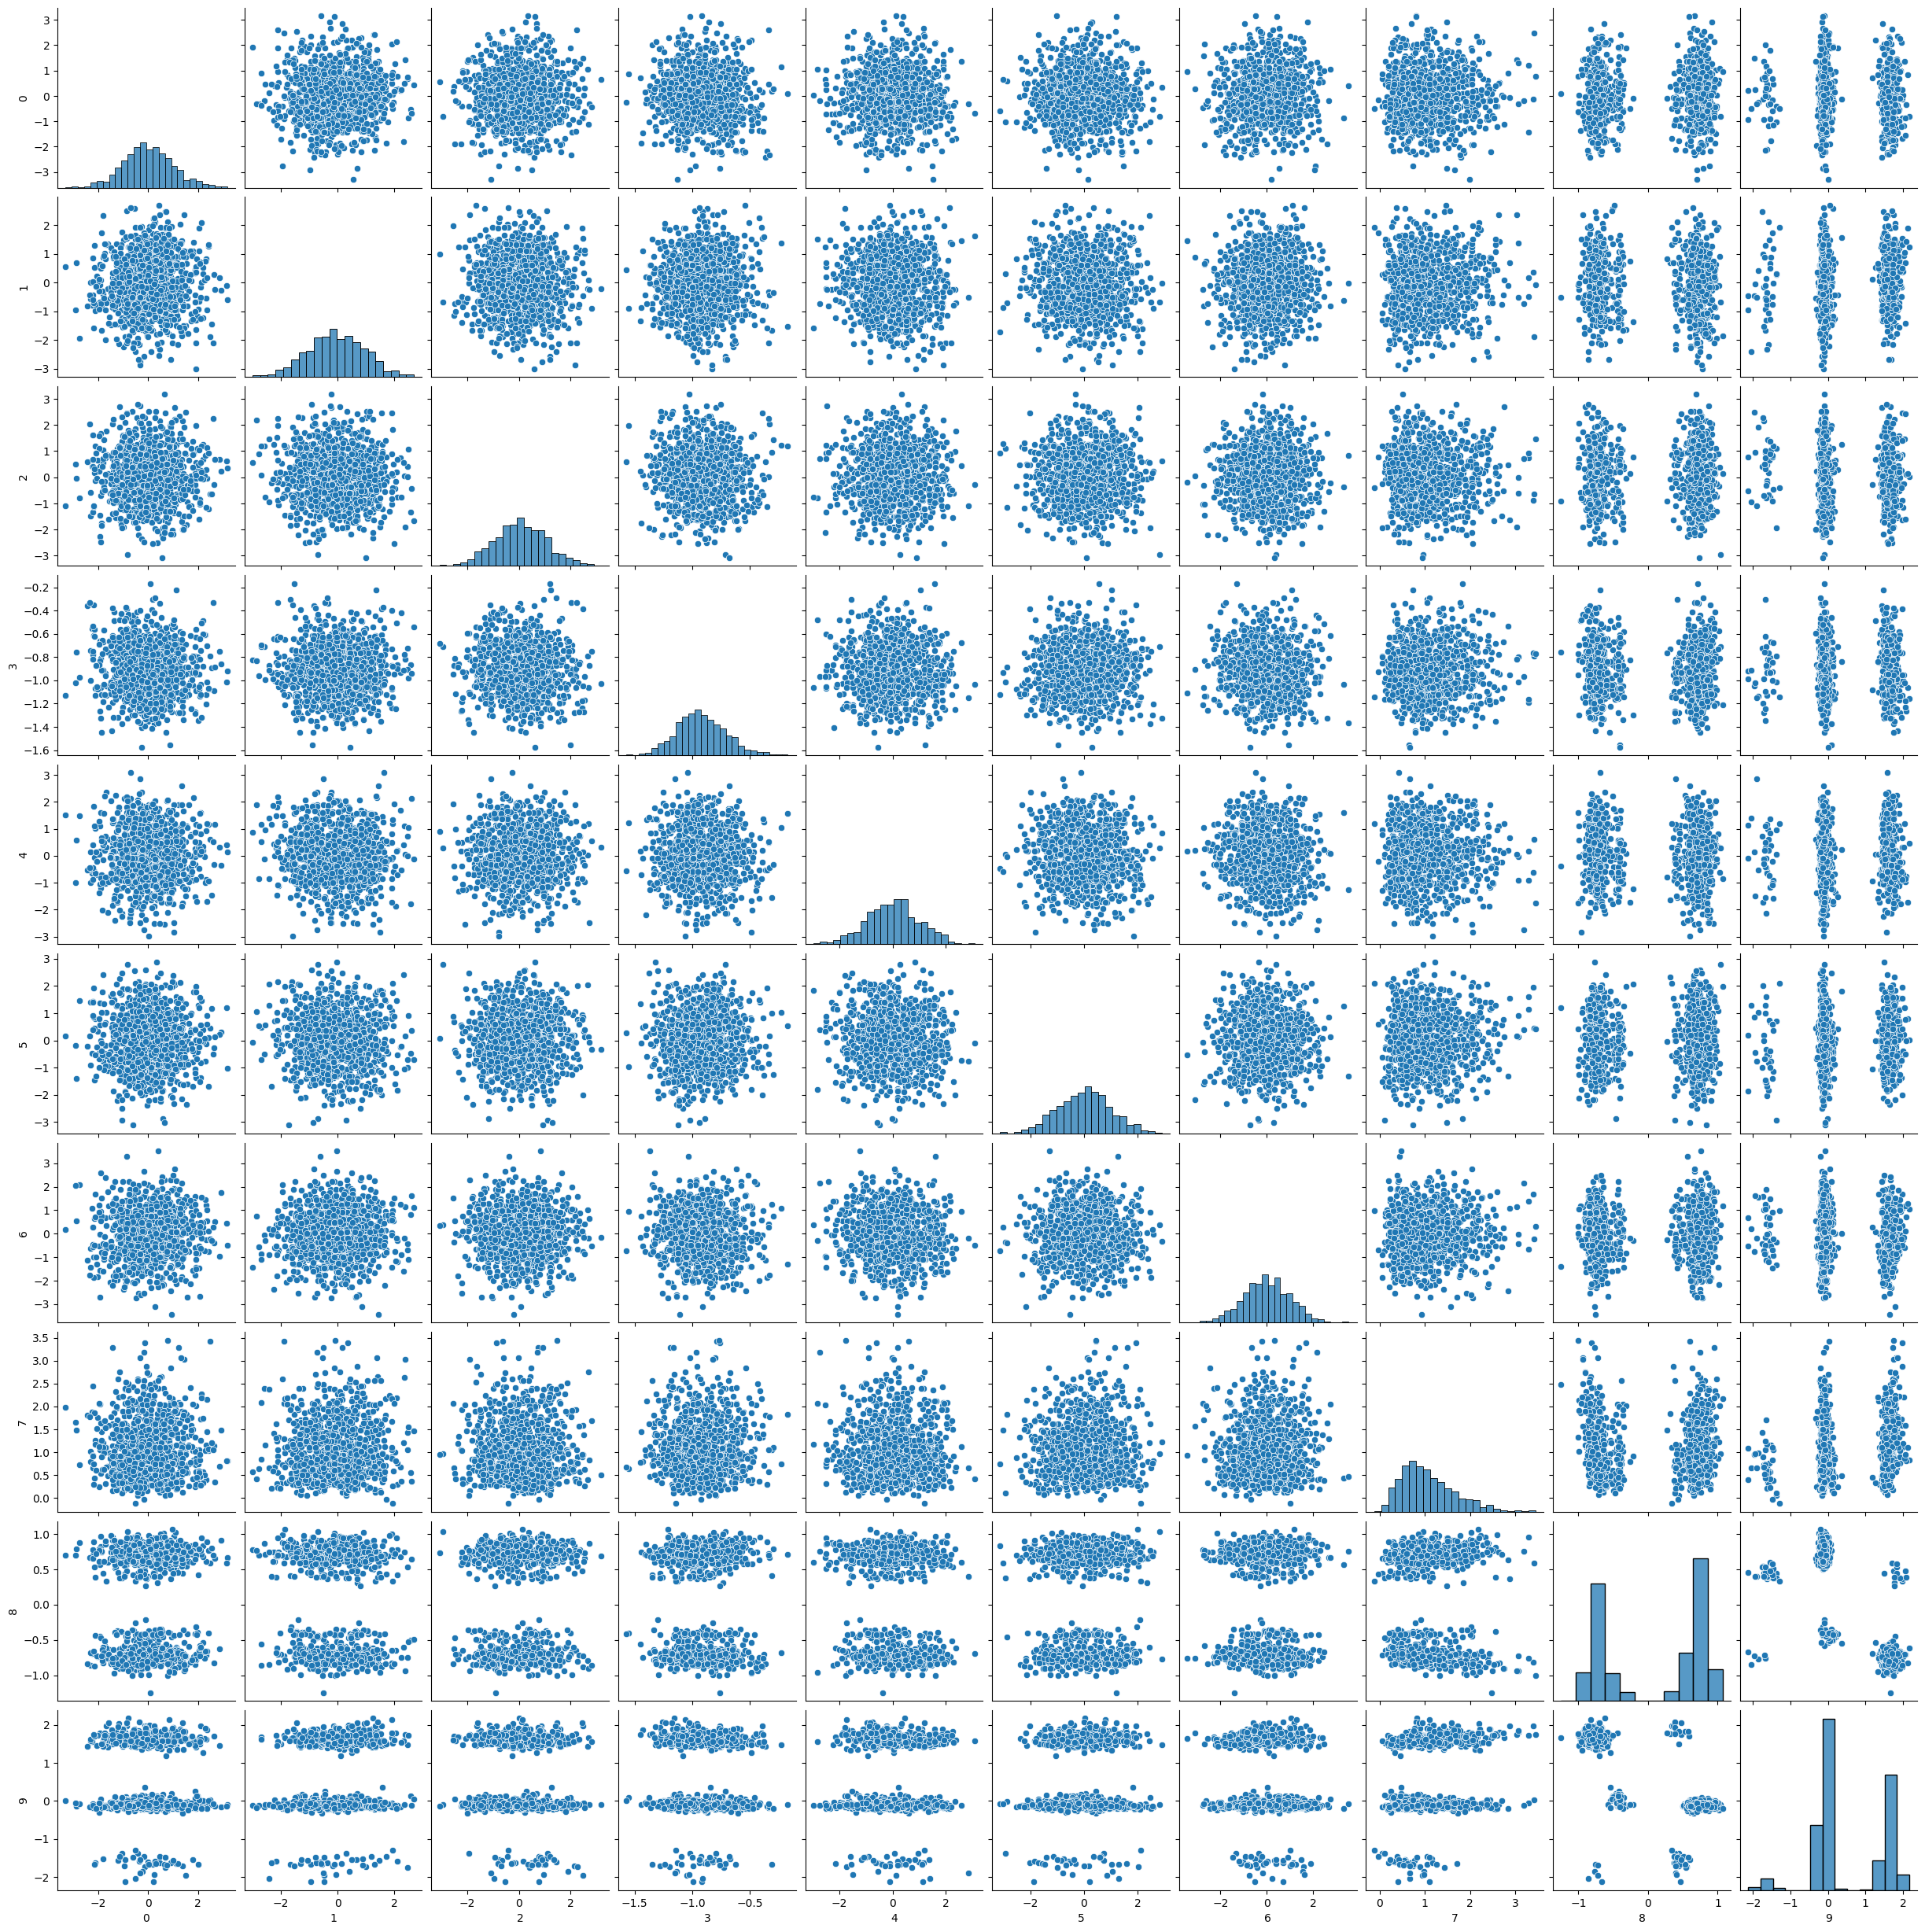

In [312]:
import seaborn as sns
import pandas as pd

sns.pairplot(pd.DataFrame(thetas_pred.reshape(-1, thetas_pred.shape[-1])))

In [313]:
def pred(key, thetas):
    params = unflatten(thetas)
    f = nnx.merge(graphdef, params)
    S = f(component, bvals, bvecs, key)
    return S

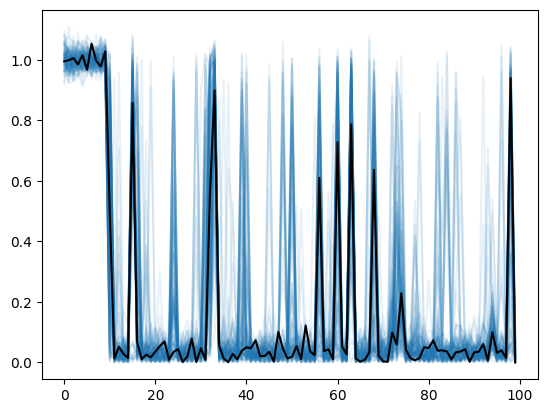

In [314]:
S_pred = jax.vmap(pred)(jax.random.split(jax.random.key(0),1000), thetas_pred)

plt.plot(S_pred[::10].T, alpha=0.1, color="C0")
plt.plot(xs[idx], color="black")